## First Neural Network on MNIST

Goal: build a simple multilayer perceptron (MLP) in PyTorch and understand:
- input shape
- forward pass
- loss computation
- basic training loop

### Steps
1. Load MNIST
2. Inspect one batch
3. Flatten images
4. Build a simple MLP
5. Run a forward pass
6. Compute loss
7. Write a manual training loop

In [2]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

import matplotlib.pyplot as plt

In [3]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(device)

mps


### Load MNIST

### What the data looks like
- Each MNIST image has shape `(1, 28, 28)`
- For an MLP, images are flattened into vectors of size `784`
- The model outputs `10` logits, one for each digit class

In [4]:
transform = transforms.ToTensor()

train_dataset = datasets.MNIST(
    root="data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root="data",
    train=False,
    download=True,
    transform=transform
)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

Inspect one batch:

In [5]:
images, labels = next(iter(train_loader))

print("images shape:", images.shape)
print("labels shape:", labels.shape)
print("first labels:", labels[:10])

images shape: torch.Size([64, 1, 28, 28])
labels shape: torch.Size([64])
first labels: tensor([3, 6, 6, 2, 5, 4, 0, 9, 5, 0])


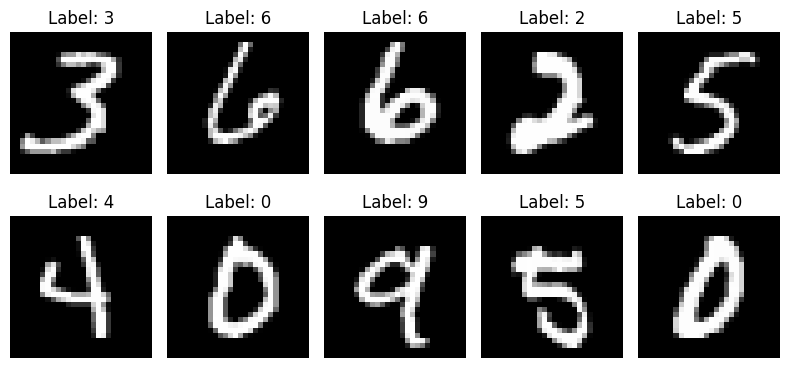

In [7]:
fig, axes = plt.subplots(2, 5, figsize=(8, 4))

for i, ax in enumerate(axes.flat):
    ax.imshow(images[i].squeeze(), cmap="gray")
    ax.set_title(f"Label: {labels[i].item()}")
    ax.axis("off")

plt.tight_layout()
plt.show()

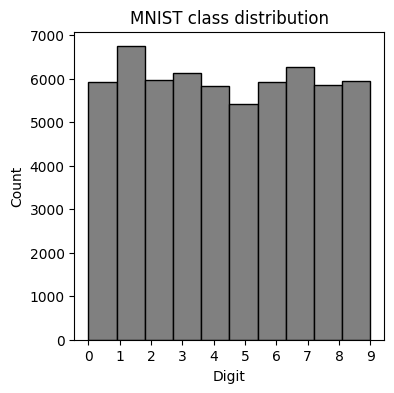

In [ ]:
all_labels = train_dataset.targets

plt.figure(figsize=(4,4))
plt.hist(all_labels.numpy(), bins=10, edgecolor="black", color='grey')
plt.xticks(range(10))
plt.xlabel("Digit")
plt.ylabel("Count")
plt.title("MNIST class distribution")
plt.show()

MLP expects vectors, not 2D images so we need to flatten them:

In [8]:
flat_images = images.view(images.size(0), -1)
print("flattened shape:", flat_images.shape)

flattened shape: torch.Size([64, 784])


### Build a simple MLP

We will start with simply: nn.Linear → ReLU → nn.Linear

In [ ]:
model = nn.Sequential(
    nn.Flatten(), # no need to flatten manually
    nn.Linear(28 * 28, 128),
    nn.ReLU(),
    nn.Linear(128, 10) # final output size is 10 because digits are 0-9
).to(device)

print(model)

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=128, bias=True)
  (2): ReLU()
  (3): Linear(in_features=128, out_features=10, bias=True)
)


### Run a forward pass

We move tensors to a device (CPU/GPU) so that computations happen on that device.

All tensors and the model must be on the same device; otherwise, PyTorch will raise an error.

Using a GPU accelerates heavy operations like matrix multiplications during the forward pass.

In [10]:
images, labels = images.to(device), labels.to(device)

logits = model(images)
print("logits shape:", logits.shape)
print(logits[:2])

logits shape: torch.Size([64, 10])
tensor([[-0.0566, -0.0008, -0.0020,  0.0946,  0.0254, -0.0849,  0.1406, -0.0430,
         -0.1056, -0.0440],
        [ 0.0125, -0.0104, -0.0592,  0.1107, -0.0383, -0.0372,  0.0244, -0.0306,
         -0.0866, -0.0715]], device='mps:0', grad_fn=<SliceBackward0>)


Output size intepretation:
- one row per image (batch size = 64)
- one score per class

Outputs are logits, but we can to turn them into probabilities for intuition:

In [11]:
probs = torch.softmax(logits, dim=1)
print(probs[:2])
print(probs[:2].sum(dim=1))

tensor([[0.0950, 0.1004, 0.1003, 0.1105, 0.1031, 0.0923, 0.1157, 0.0963, 0.0904,
         0.0962],
        [0.1030, 0.1007, 0.0959, 0.1136, 0.0979, 0.0980, 0.1042, 0.0987, 0.0933,
         0.0947]], device='mps:0', grad_fn=<SliceBackward0>)
tensor([1., 1.], device='mps:0', grad_fn=<SumBackward1>)


Each row sums to 1.

We can also inspect predictions:

In [12]:
preds = probs.argmax(dim=1)
print("predictions:", preds[:10])
print("true labels:", labels[:10])

predictions: tensor([6, 3, 6, 6, 3, 6, 3, 6, 6, 3], device='mps:0')
true labels: tensor([3, 6, 6, 2, 5, 4, 0, 9, 5, 0], device='mps:0')


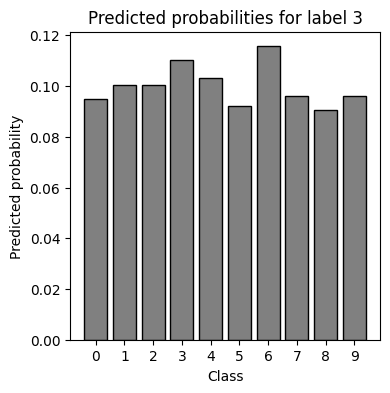

In [22]:
idx = 0
plt.figure(figsize=(4, 4))
plt.bar(range(10), probs[idx].detach().cpu().numpy(), color='grey', edgecolor='black')
plt.xticks(range(10))
plt.xlabel("Class")
plt.ylabel("Predicted probability")
plt.title(f"Predicted probabilities for label {labels[idx].item()}")
plt.show()

It's ok: it's the initial forward pass for predictions are bad.

### Compute loss

For multiclass classification, we use cross-entropy:

In [13]:
criterion = nn.CrossEntropyLoss()
loss = criterion(logits, labels)

print("loss:", loss.item())

loss: 2.305819511413574


Important: cross-entropy excepts raw-logits, so do not apply softmax (-> probabilities) before loss during training.

### Minimal manual training loop

In [26]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

num_epochs = 10
train_losses = []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)
    train_losses.append(epoch_loss)

    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {epoch_loss:.4f}")

Epoch 1/10, Loss: 0.0836
Epoch 2/10, Loss: 0.0654
Epoch 3/10, Loss: 0.0513
Epoch 4/10, Loss: 0.0430
Epoch 5/10, Loss: 0.0342
Epoch 6/10, Loss: 0.0290
Epoch 7/10, Loss: 0.0239
Epoch 8/10, Loss: 0.0199
Epoch 9/10, Loss: 0.0167
Epoch 10/10, Loss: 0.0134


Quick evaluation loop:

In [27]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        logits = model(images)
        preds = logits.argmax(dim=1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

test_acc = correct / total
print(f"Test accuracy: {test_acc:.4f}")

Test accuracy: 0.9786


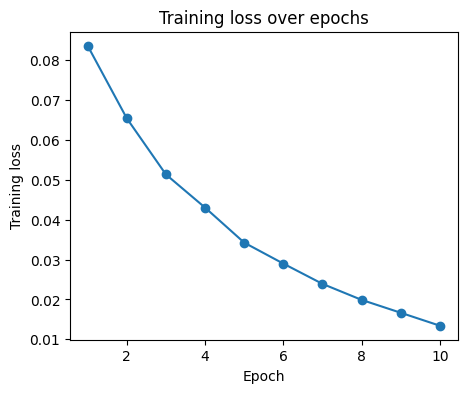

In [28]:
plt.figure(figsize=(5, 4))
plt.plot(range(1, num_epochs + 1), train_losses, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Training loss")
plt.title("Training loss over epochs")
plt.show()